In [113]:
import numpy as np
import pandas as pd
import cv2
from pathlib import Path
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

In [114]:
df = pd.read_csv("dataset_clean.csv")
df.head()

,image_url,description,country,weather,time_of_day,season,activity,mood,local_image_path
0,https://commons.wikimedia.org/wiki/File:Dom_of...,A clear image of the Dome of the Rock in Jerus...,Palestine,Sunny,Afternoon,summer,Sightseeing,Romantic,images/image_0.jpg
1,https://upload.wikimedia.org/wikipedia/commons...,a clear image of the Ibrahimi Mosque (Cave of ...,Palestine,Sunny,Morning,spring,Sightseeing,Curious,images/image_1.jpg
2,https://upload.wikimedia.org/wikipedia/commons...,A clear image of Mar Saba Monastery in Bethleh...,Palestine,Sunny,Afternoon,summer,Sightseeing,Curious,images/image_3.jpg
3,https://upload.wikimedia.org/wikipedia/commons...,A clear aerial view of Tell es-Sultan in Jeric...,Palestine,Sunny,Morning,spring,Exploring,Curious,images/image_4.jpg
4,https://upload.wikimedia.org/wikipedia/commons...,A night view of the Eiffel Tower illuminated i...,France,Not Clear,Afternoon,not clear,Sightseeing,Romantic,images/image_5.jpg


### Extraxt Fetures 

In [ ]:

def extract_hsv_histogram(image, bins=32):
    try:
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        features = []        
        h_hist = cv2.calcHist([hsv], [0], None, [bins], [0, 180])
        features.extend(h_hist.flatten())        
        s_hist = cv2.calcHist([hsv], [1], None, [bins], [0, 256])
        features.extend(s_hist.flatten())
        v_hist = cv2.calcHist([hsv], [2], None, [bins], [0, 256])
        features.extend(v_hist.flatten())
        
        return np.array(features)
    except Exception as e:
        print(f"Error in HSV extraction: {e}")
        return np.zeros(bins * 3)

In [13]:
def extract_basic_stats(image):
    features = []
    for i in range(3):
        channel = image[:, :, i]
        features.extend([
            np.mean(channel),
            np.std(channel),
        ])
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    features.append(np.mean(gray))
    return np.array(features)

In [115]:
def extract_image_features(image_path, method='combined'):
    image = cv2.imread(str(image_path))
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")
    image = cv2.resize(image, (256, 256))
    features = []
    if method in ['histogram', 'combined']:
        features.append(extract_hsv_histogram(image, bins=32))
    if method in ['stats', 'combined']:
        features.append(extract_basic_stats(image))
    
    return np.concatenate(features)


### STEP 3: EXTRACT FEATURES FROM ALL IMAGES

In [18]:
feature_list = []
valid_indices = []

for idx, img_path in enumerate(tqdm(df["local_image_path"], desc="Processing images")):
    try:
        features = extract_image_features(img_path, method="combined")
        feature_list.append(features)
        valid_indices.append(idx)
    except Exception as e:
        print(f"Error processing {img_path}: {e}")

X = np.array(feature_list)
y = df.loc[valid_indices, ["weather", "mood"]].values

Processing images:   0%|          | 3/864 [00:00<00:53, 16.23it/s]

Error processing images/image_0.jpg: Could not read image: images/image_0.jpg


Processing images:   6%|▋         | 55/864 [00:14<04:45,  2.83it/s]

Error processing images/image_61.jpg: Could not read image: images/image_61.jpg


Processing images:   9%|▉         | 80/864 [00:16<00:33, 23.60it/s]

...

Processing images:  88%|████████▊ | 758/864 [01:40<00:01, 53.51it/s]

Error processing images/image_814.jpg: Could not read image: images/image_814.jpg
Error processing images/image_815.jpg: Could not read image: images/image_815.jpg
Error processing images/image_816.jpg: Could not read image: images/image_816.jpg
Error processing images/image_817.jpg: Could not read image: images/image_817.jpg
Error processing images/image_818.jpg: Could not read image: images/image_818.jpg
Error processing images/image_819.jpg: Could not read image: images/image_819.jpg
Error processing images/image_820.jpg: Could not read image: images/image_820.jpg
Error processing images/image_821.jpg: Could not read image: images/image_821.jpg
Error processing images/image_822.jpg: Could not read image: images/image_822.jpg
Error processing images/image_823.jpg: Could not read image: images/image_823.jpg


Processing images:  97%|█████████▋| 841/864 [01:58<00:01, 15.34it/s]

Error processing images/image_917.jpg: Could not read image: images/image_917.jpg


Processing images: 100%|██████████| 864/864 [01:59<00:00,  7.23it/s]


In [116]:
print(f"Feature matrix shape: {X.shape}")
print(f"Target matrix shape: {y.shape}")
print(f"Number of features per image: {X.shape[1]}")


Feature matrix shape: (800, 103)
Target matrix shape: (800, 1)
Number of features per image: 103


In [117]:
print("\nClass distribution:")
print("Weather:", np.unique(y[:, 0], return_counts=True))


Class distribution:
Weather: (array(['Cloudy', 'Not Clear', 'Rainy', 'Snowy', 'Sunny'], dtype=object), array([165,  78,  18,  71, 468]))


In [51]:
X = np.array(feature_list)
y = df.loc[valid_indices, ["weather"]].values


In [52]:
print(f"Feature matrix shape: {X.shape}")
print(f"Number of features per image: {X.shape[1]}")

Feature matrix shape: (800, 103)
Number of features per image: 103


In [53]:

print(f"Features shape: {X.shape}")
print(f"Targets shape: {y.shape}")



Features shape: (800, 103)
Targets shape: (800, 1)


In [ ]:
le_weather = LabelEncoder()
y_weather = le_weather.fit_transform(y[:, 0])
y_weather.shape


(800,)


### split dataset

In [88]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_weather,
    test_size=0.30,
    random_state=42,

)


In [89]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
)

### Random forrest classification 

In [112]:
max_depths = [5,10, 20, 30]


best_score = 0
best_params = {}

print("\nTuning max_depth...")
for d in max_depths:
    model  = RandomForestClassifier(
        n_estimators=100,  
        max_depth=d,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    
    y_pred_val = model.predict(X_val)
    acc_weather = accuracy_score(y_val, y_pred_val)
    
    print(f"  max_depth={d} -> Weather: {acc_weather}")
    
    if acc_weather > best_score:
        best_score = acc_weather
        best_params['max_depth'] = d



Tuning max_depth...
  max_depth=5 -> Weather: 0.6583333333333333
  max_depth=10 -> Weather: 0.6666666666666666
  max_depth=20 -> Weather: 0.65
  max_depth=30 -> Weather: 0.6416666666666667


In [111]:
min_samples_leafs = [1, 2, 4, 8]

print("\nTuning min_samples_leaf...")
best_score = 0
for leaf in min_samples_leafs:
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=best_params['max_depth'],
        min_samples_leaf=leaf,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    
    y_pred_val = model.predict(X_val)
    acc_weather = accuracy_score(y_val, y_pred_val)

    
    print(f"  min_samples_leaf={leaf} -> Weather: {acc_weather:.4f}")
    
    if acc_weather > best_score:
        best_score = acc_weather
        best_params['min_samples_leaf'] = leaf




Tuning min_samples_leaf...
  min_samples_leaf=1 -> Weather: 0.6667
  min_samples_leaf=2 -> Weather: 0.6667
  min_samples_leaf=4 -> Weather: 0.6500
  min_samples_leaf=8 -> Weather: 0.6250


In [110]:
for param, value in best_params.items():
    print(f"  {param}: {value}")

  max_depth: 10
  min_samples_leaf: 1


In [63]:
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)


y_train shape: (560,)
y_val shape: (120,)


### STEP 6: TRAIN FINAL MODEL WITH BEST PARAMETERS

In [ ]:
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val], axis=0)

print(f"Training on {X_train_full.shape[0]} samples (train + val)")

final_model = RandomForestClassifier(
    n_estimators=300,  # Use more trees for final model
    max_depth=best_params['max_depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_full, y_train_full)


Training on 680 samples (train + val)
✓ Final model trained!


### EVALUATE ON TEST SET

In [105]:
y_pred_test = final_model.predict(X_test)

acc_weather = accuracy_score(y_test, y_pred_test)
f1_weather = f1_score(y_test, y_pred_test, average="macro")

print("\nWEATHER CLASSIFICATION:")
print(f"  Accuracy: {acc_weather:.4f} ({acc_weather*100:.2f}%)")
print(f"  F1 Score (macro): {f1_weather:.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_test))


WEATHER CLASSIFICATION:
  Accuracy: 0.6667 (66.67%)
  F1 Score (macro): 0.5155

Detailed Report:
              precision    recall  f1-score   support

           0       0.44      0.17      0.25        23
           1       0.67      0.55      0.60        11
           2       1.00      0.33      0.50         3
           3       0.80      0.31      0.44        13
           4       0.68      0.93      0.78        70

    accuracy                           0.67       120
   macro avg       0.72      0.46      0.52       120
weighted avg       0.65      0.67      0.62       120



In [106]:
y_true = y_test  

try:
    y_true_decoded = le_weather.inverse_transform(y_true)
    y_pred_decoded = le_weather.inverse_transform(y_pred_test)
except:
    y_true_decoded = y_true
    y_pred_decoded = y_pred_test
    
cm = confusion_matrix(y_test, y_pred_test)
labels = sorted(np.unique(y_true_decoded))

per_class = []
for i, label in enumerate(labels):
    total = cm[i, :].sum()
    correct = cm[i, i]
    acc = correct / total if total > 0 else 0
    per_class.append({'class': label, 'accuracy': acc, 'samples': total, 'errors': total - correct})

per_class_df = pd.DataFrame(per_class).sort_values('accuracy')
print(per_class_df.to_string(index=False))

    class  accuracy  samples  errors
   Cloudy  0.173913       23      19
    Snowy  0.307692       13       9
    Rainy  0.333333        3       2
Not Clear  0.545455       11       5
    Sunny  0.928571       70       5


In [107]:
confusions = []
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j and cm[i, j] > 0:
            confusions.append({
                'true→pred': f"{labels[i]}→{labels[j]}",
                'count': cm[i, j],
                'pct': f"{cm[i, j]/cm[i, :].sum()*100:.1f}%"
            })

confusion_df = pd.DataFrame(confusions).sort_values('count', ascending=False).head(10)
print(confusion_df.to_string(index=False))

       true→pred  count   pct
    Cloudy→Sunny     18 78.3%
     Snowy→Sunny      6 46.2%
 Not Clear→Sunny      5 45.5%
    Snowy→Cloudy      3 23.1%
     Rainy→Sunny      2 66.7%
 Sunny→Not Clear      2  2.9%
    Sunny→Cloudy      2  2.9%
Cloudy→Not Clear      1  4.3%
     Sunny→Snowy      1  1.4%


In [108]:
class_counts = pd.Series(y_true_decoded).value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()

worst_class = per_class_df.iloc[0]

print(f"\nBest class: {per_class_df.iloc[-1]['class']} ({per_class_df.iloc[-1]['accuracy']:.2%})")
print(f"Worst class: {worst_class['class']} ({worst_class['accuracy']:.2%})")
print(f"Class imbalance ratio: {imbalance_ratio:.1f}:1")
if imbalance_ratio > 3:
    print("High imbalance - consider balancing techniques")

if len(confusion_df) > 0:
    top = confusion_df.iloc[0]
    print(f"Most common confusion: {top['true→pred']} ({top['count']} times)")



Best class: Sunny (92.86%)
Worst class: Cloudy (17.39%)
Class imbalance ratio: 23.3:1
High imbalance - consider balancing techniques
Most common confusion: Cloudy→Sunny (18 times)


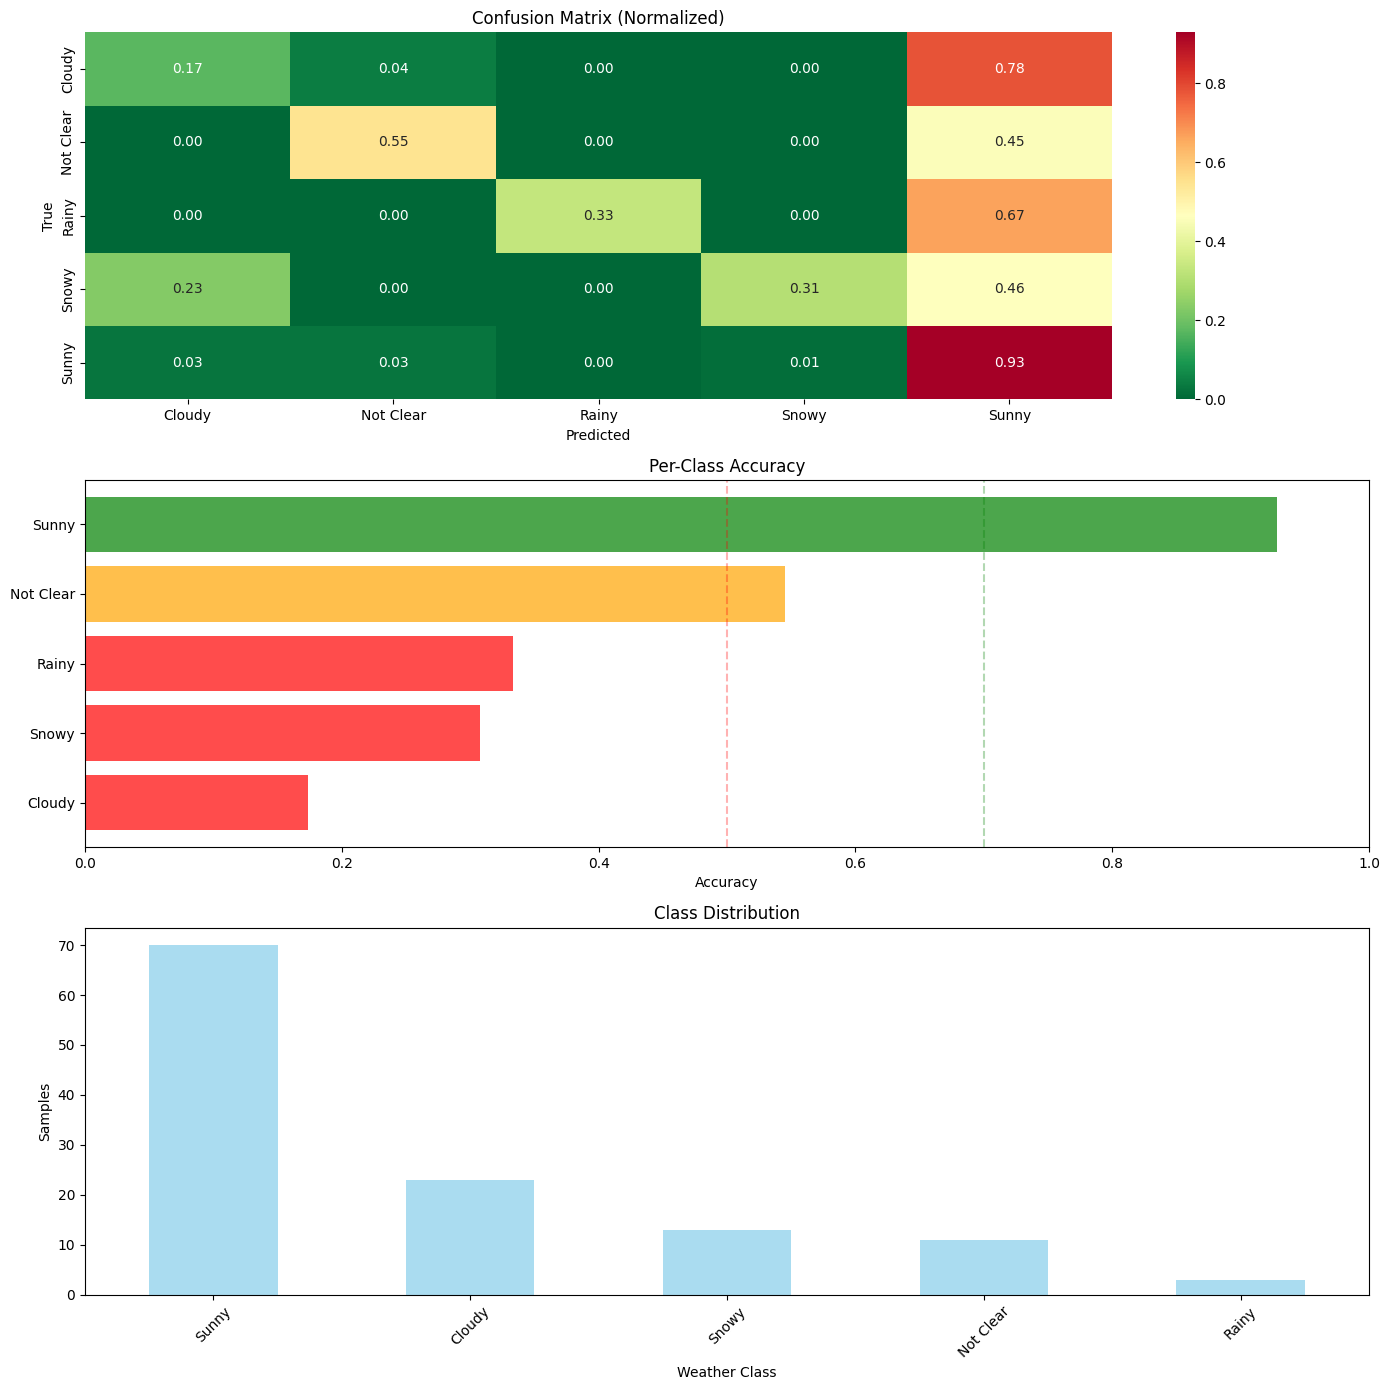

In [109]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='RdYlGn_r',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Confusion Matrix (Normalized)')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

colors = ['red' if acc < 0.5 else 'orange' if acc < 0.7 else 'green'
          for acc in per_class_df['accuracy']]
axes[1].barh(per_class_df['class'], per_class_df['accuracy'], color=colors, alpha=0.7)
axes[1].set_xlabel('Accuracy')
axes[1].set_title('Per-Class Accuracy')
axes[1].set_xlim([0, 1])
axes[1].axvline(x=0.7, color='green', linestyle='--', alpha=0.3)
axes[1].axvline(x=0.5, color='red', linestyle='--', alpha=0.3)

class_counts.plot(kind='bar', ax=axes[2], color='skyblue', alpha=0.7)
axes[2].set_title('Class Distribution')
axes[2].set_xlabel('Weather Class')
axes[2].set_ylabel('Samples')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
